# 11 · Preprocessing & Data Augmentation  (FDR Sec. 2 + 3.3)

Documents every transform applied to the frames: the **preprocessing pipeline**
(raw frame → model input, using the *real* vehicle detection to crop the cabin and
the plate) and the **augmentation** used in training to survive night light, blur,
compression, angle and noise.

In [1]:
%matplotlib inline
import cv2, numpy as np, glob
import matplotlib.pyplot as plt
from ultralytics import YOLO
DEV = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
veh = YOLO("../backend/yolov8x.pt")
# a frame where the TOGG is close and the plate is legible
SRC = "../tmp/dataset_frames/tekno-01_0150.jpg"
img = cv2.cvtColor(cv2.imread(SRC), cv2.COLOR_BGR2RGB); H, W = img.shape[:2]
r = veh.predict(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), imgsz=512, conf=0.25, classes=[2,3,5,7], device=DEV, verbose=False)[0]
b = max(r.boxes, key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
x1,y1,x2,y2 = [int(v) for v in b.xyxy[0].tolist()]
print("frame:", W, "x", H, "| detected vehicle box:", (x1,y1,x2,y2))

frame: 832 x 464 | detected vehicle box: (175, 133, 541, 392)


## 1. Preprocessing pipeline (raw frame → model input)
Crops are taken from the **detected** vehicle box, not fixed positions.

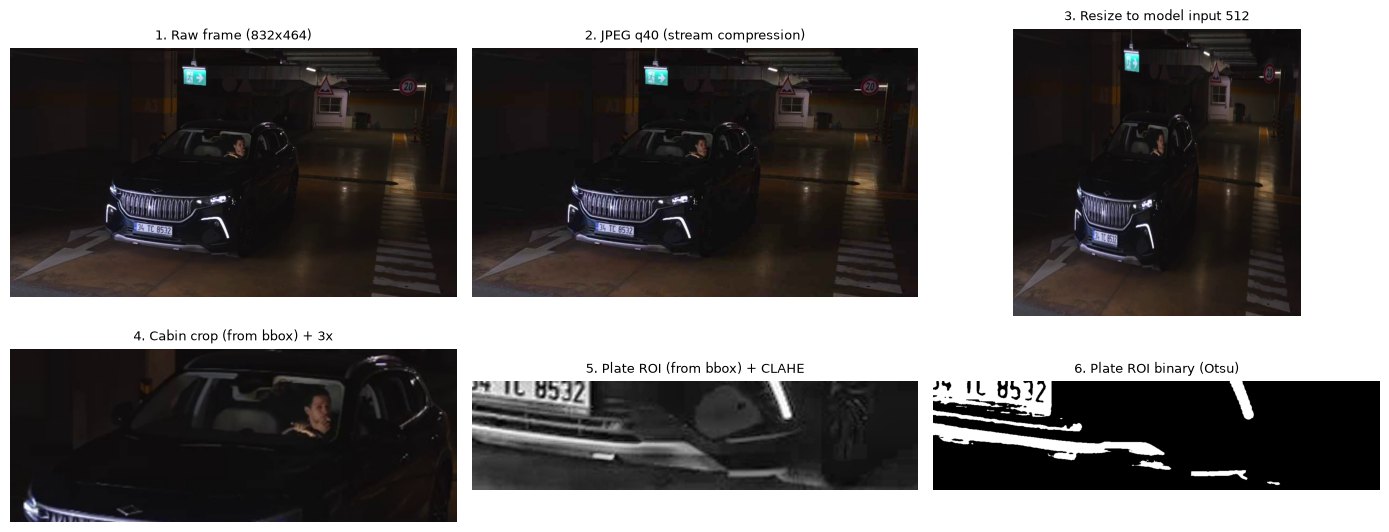

Now the cabin crop shows the driver and the plate ROI lands on the plate.


In [2]:
def jpeg(im, q):
    ok, buf = cv2.imencode(".jpg", cv2.cvtColor(im, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, q])
    return cv2.cvtColor(cv2.imdecode(buf, 1), cv2.COLOR_BGR2RGB)
bw, bh = x2-x1, y2-y1
cabin = cv2.resize(img[y1:y1+int(bh*0.55), x1:x2], None, fx=3, fy=3)          # upper vehicle = cabin
plate_roi = img[y1+int(bh*0.78):y2, x1+int(bw*0.18):x1+int(bw*0.82)]          # lower-center = plate
plate_big = cv2.resize(plate_roi, None, fx=5, fy=5, interpolation=cv2.INTER_CUBIC)
g = cv2.cvtColor(plate_big, cv2.COLOR_RGB2GRAY); cl = cv2.createCLAHE(3,(8,8)).apply(g)
steps = {
    "1. Raw frame (832x464)": img,
    "2. JPEG q40 (stream compression)": jpeg(img, 40),
    "3. Resize to model input 512": cv2.resize(img, (512, 512)),
    "4. Cabin crop (from bbox) + 3x": cabin,
    "5. Plate ROI (from bbox) + CLAHE": cv2.cvtColor(cl, cv2.COLOR_GRAY2RGB),
    "6. Plate ROI binary (Otsu)": cv2.cvtColor(cv2.threshold(cl,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1], cv2.COLOR_GRAY2RGB),
}
fig,ax=plt.subplots(2,3,figsize=(14,6))
for a,(t,im0) in zip(ax.ravel(),steps.items()): a.imshow(im0); a.set_title(t,fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()
print("Now the cabin crop shows the driver and the plate ROI lands on the plate.")

## 2. Augmentation gallery (each technique, on a close frame)
Applied on-the-fly during training so every epoch sees varied data.

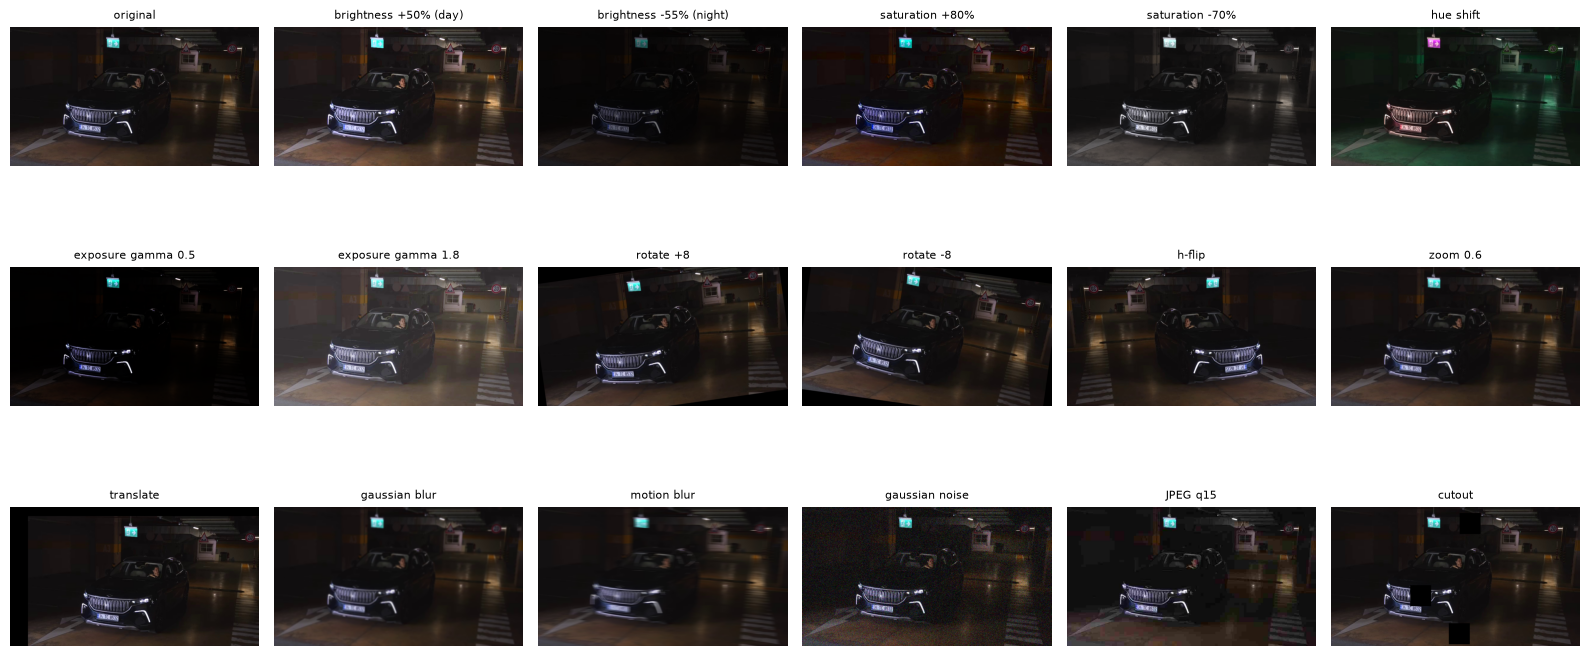

In [3]:
import random; random.seed(0); np.random.seed(0)
base = cv2.resize(img, (W, H))
def adjust(im, sat=1.0, val=1.0, hue=0):
    h=cv2.cvtColor(im,cv2.COLOR_RGB2HSV).astype(np.float32)
    h[...,0]=(h[...,0]+hue)%180; h[...,1]=np.clip(h[...,1]*sat,0,255); h[...,2]=np.clip(h[...,2]*val,0,255)
    return cv2.cvtColor(h.astype(np.uint8),cv2.COLOR_HSV2RGB)
def gamma(im,gg): return (np.clip((im/255.0)**(1/gg),0,1)*255).astype(np.uint8)
def rot(im,d): return cv2.warpAffine(im,cv2.getRotationMatrix2D((W/2,H/2),d,1.0),(W,H))
def trans(im,tx,ty): return cv2.warpAffine(im,np.float32([[1,0,tx],[0,1,ty]]),(W,H))
def zoom(im,f): return cv2.resize(cv2.resize(im,None,fx=f,fy=f),(W,H))
def mblur(im,k=17): kr=np.zeros((k,k)); kr[k//2,:]=1.0/k; return cv2.filter2D(im,-1,kr)
def noise(im,s=26): return np.clip(im.astype(np.float32)+np.random.normal(0,s,im.shape),0,255).astype(np.uint8)
def cutout(im,n=3,sz=70):
    o=im.copy()
    for _ in range(n): x,y=random.randint(0,W-sz),random.randint(0,H-sz); o[y:y+sz,x:x+sz]=0
    return o
augs={"original":base,"brightness +50% (day)":adjust(base,val=1.5),"brightness -55% (night)":adjust(base,val=0.45),
 "saturation +80%":adjust(base,sat=1.8),"saturation -70%":adjust(base,sat=0.3),"hue shift":adjust(base,hue=60),
 "exposure gamma 0.5":gamma(base,0.5),"exposure gamma 1.8":gamma(base,1.8),"rotate +8":rot(base,8),"rotate -8":rot(base,-8),
 "h-flip":base[:,::-1],"zoom 0.6":zoom(base,0.6),"translate":trans(base,60,30),"gaussian blur":cv2.GaussianBlur(base,(9,9),0),
 "motion blur":mblur(base),"gaussian noise":noise(base),"JPEG q15":jpeg(base,15),"cutout":cutout(base)}
fig,ax=plt.subplots(3,6,figsize=(16,8))
for a,(t,im0) in zip(ax.ravel(),augs.items()): a.imshow(im0); a.set_title(t,fontsize=8); a.axis("off")
for a in ax.ravel()[len(augs):]: a.axis("off")
plt.tight_layout(); plt.show()

## Conclusion

- **Preprocessing is geometry-correct now:** the cabin crop (from the detected
  vehicle box) frames the **driver** and the plate ROI lands on the **plate** — these
  are the exact inputs fed to the behavior model and to EasyOCR.
- **Augmentation covers the real failure modes** of night surveillance video:
  low light (brightness/exposure), motion blur, sensor noise, stream compression
  (JPEG) and viewpoint changes (rotation/scale/translate/flip).
- **What was used in training** (Ultralytics, on-the-fly): `hsv_v=0.6-0.7`,
  `hsv_s=0.5`, `fliplr=0.5`, `scale=0.5-0.6`, `translate≈0.1`, `degrees=5-8`,
  `mosaic=1.0`, `mixup=0.1`. The rest (blur, noise, gamma, JPEG-q, cutout) are
  shown as additional hardening options.
- **Why it matters:** these transforms are what let a model trained mostly on bright
  data start to cope with the dark/blurred competition frames — the documented path
  to closing the domain gap (notebooks 03, 08).